# 01211373 : Machine Learning and Programming for Industry

## Lecture 5 Supplement 2 : Clustering Analysis

In this lecture we continue with unsupervised learning algorithms that do not require labeled data. We particularly address clustering, a data analysis technique aimed at grouping together data with similarity.

**Note :** For this semester (2026), we cover only k-means clustering and DBSCAN.


### 8.1 k-means clustering

The K-means algorithm is an iterative unsupervised machine learning technique used to partition a dataset into a predefined number of K clusters. It works by repeatedly assigning each data point to the nearest cluster centroid (the mean of all points in that cluster) and then recalculating the centroids until cluster assignments no longer change. The goal is to minimize the sum of distances between data points and their assigned cluster centroids. 

From Chapter 10 of [2].

In the clustering problem, we are given a training set $\{x^{(1)}, \ldots , x^{(n)} \}$, aand
want to group the data into a few cohesive "clusters." Here, $x^{(i)} \in \mathbb{R}^d$ as usual; but no labels $y^{(i)}$ are given. So, this is an unsupervised learning problem.

<hr>

The k-means clustering algorithm is as follows:

1. Initialize **cluster centroids** $\mu_1, \mu_2, \ldots , \mu_k \in \mathbb{R}^d$ randomly.

2. Repeat until convergence:  {

&nbsp; &nbsp; For every $i$ set
$$
c^{(i)} := arg \; \underset{j}{min} \; \lVert x^{(i)} - \mu_j \rVert ^2. \tag{8.1}
$$

&nbsp; &nbsp; For each $j$ set
$$
\mu_j := \frac{\sum_{i=1}^n 1\{c^{(i)} = j\}x^{(i)}}{\sum_{i=1}^n 1\{c^{(i)} = j\}} \tag{8.2}
$$
}

<hr>

In the algorithm above, $k$ (a parameter of the algorithm) is the number
of clusters we want to find; and the cluster centroids $\mu_j$ represent our current
guesses for the positions of the centers of the clusters. To initialize the cluster
centroids (in step 1 of the algorithm above), we could choose $k$ training
examples randomly, and set the cluster centroids to be equal to the values of
these $k$ examples. (Other initialization methods are also possible.)

The inner-loop of the algorithm repeatedly carries out two steps: (i)
“Assigning” each training example $x^{(i)}$ to the closest cluster centroid $\mu_j$
, and (ii) Moving each cluster centroid $\mu_j$ to the mean of the points assigned to it.

Is the k-means algorithm guaranteed to converge? Yes it is, in a certain
sense. In particular, let us define the distortion function to be
$$
J(c,\mu) = \sum_{i=1}^n \lVert x^{(i)} - \mu_{c^{(i)}} \rVert ^2 \tag{8.3}
$$
Thus, $J$ measures the sum of squared distances between each training example $x^{(i)}$ and the cluster centroid $\mu_{c^{(i)}}$ to which it has been assigned. It can
be shown that k-means is exactly coordinate descent on $J$. Specifically, the
inner-loop of k-means repeatedly minimizes $J$ with respect to $c$ while holding
$\mu$ fixed, and then minimizes $J$ with respect to $\mu$ while holding $c$ fixed. Thus, 
$J$ must monotonically decrease, and the value of $J$ must converge. 
(Usually, this implies that $c$ and $\mu$ will converge too. In theory, it is possible for
k-means to oscillate between a few different clusterings—i.e., a few different
values for $c$ and/or $\mu$ -- that have exactly the same value of $J$, but this almost
never happens in practice.)

The distortion function $J$ is a non-convex function, and so coordinate
descent on $J$ is not guaranteed to converge to the global minimum. In other
words, k-means can be susceptible to local optima. Very often k-means will
work fine and come up with very good clusterings despite this. But if you
are worried about getting stuck in bad local minima, one common thing to
do is run k-means many times (using different random initial values for the
cluster centroids $\mu_j$ ). Then, out of all the different clusterings found, pick
the one that gives the lowest distortion $J(c,\mu)$.

#### 8.1.1 Examine how k-means algorithm works

Here we implement k-means algorithm to see the progress in each step. Try adjusting initial centroid locations and we can see that some results in different local minimum that's not so good.

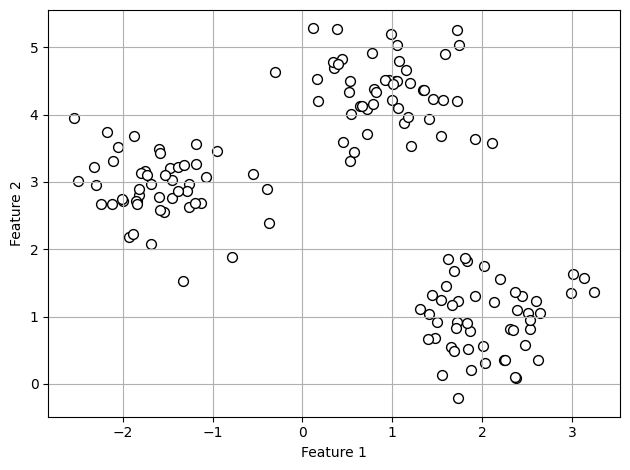

In [10]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=150, 
                  n_features=2, 
                  centers=3, 
                  cluster_std=0.5, 
                  shuffle=True, 
                  random_state=0)



plt.scatter(X[:, 0], X[:, 1], 
            c='white', marker='o', edgecolor='black', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.grid()
plt.tight_layout()
plt.show()


In [155]:
# Our naive implementation of k-means, just to demonstrate how it works 
# Beware : this implementation will fail for some initialization that results in zero assignment
# for a class

class k_Means_2D:
    def __init__(self, n_clusters=3,max_iter=50,tol=1e-3, random_state = 1):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol 
        self.random_state = random_state
        self.num_samples = X.shape[0]
        rgen = np.random.RandomState(self.random_state)
        self.cluster_centroids_ = rgen.normal(loc=0.0, scale=1.0, size=(self.n_clusters,2))
        # self.cluster_centroids_[1,:] += np.array([1.0,3.0])  # This results in local minimum
        self.cluster_centroids_[2,:] += 3.0
        self.y = np.zeros((self.num_samples),dtype=int)
        self.errors = 1.0 

    def step(self,X):  # progress each step according to (8.1),(8.2) 
        # (8.1)
        for i in range(self.num_samples): 
            self.y[i] = np.argmin(np.linalg.norm(X[i,:] - self.cluster_centroids_,ord=2,axis=1)**2)
        return self.y

    def compute_new_centroids(self):
        # (8.2)
        old_centroids = self.cluster_centroids_
        self.cluster_centroids_ = np.zeros((3,2))
        for i in range(self.num_samples):
            for j in range(self.n_clusters):
                self.cluster_centroids_[j,:] += np.where(self.y[i]==j,X[i,:],0)
        bincounts = np.bincount(self.y) # must make sure that each class has some examples
        for j in range(self.n_clusters):
            self.cluster_centroids_[j] /= bincounts[j]
        self.errors = np.linalg.norm(self.cluster_centroids_ - old_centroids)

    def fit_predict(self, X):
        n_iter = 0
        while n_iter < self.max_iter and self.errors > self.tol:
            self.step(X)
            self.compute_new_centroids()
            n_iter += 1
        print("Iteration : "+ str(n_iter))
        print("Centroid change : " + str(self.errors))
        return self.y


        


In [101]:
# plot function
def plot_km():
    plt.scatter(X[my_y_km == 0, 0],
                X[my_y_km == 0, 1],
                s=50, c='lightgreen',
                marker='s', edgecolor='black',
                label='Cluster 1')
    plt.scatter(X[my_y_km == 1, 0],
                X[my_y_km == 1, 1],
                s=50, c='orange',
                marker='o', edgecolor='black',
                label='Cluster 2')
    plt.scatter(X[my_y_km == 2, 0],
                X[my_y_km == 2, 1],
                s=50, c='lightblue',
                marker='v', edgecolor='black',
                label='Cluster 3')
    plt.scatter(my_km.cluster_centroids_[:, 0],
                my_km.cluster_centroids_[:, 1],
                s=250, marker='*',
                c='red', edgecolor='black',
                label='Centroids')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    plt.legend(scatterpoints=1)
    plt.grid()
    plt.tight_layout()
    plt.show()    

In [142]:
my_km = k_Means_2D(n_clusters=3)

In [143]:
my_y_km = my_km.step(X)

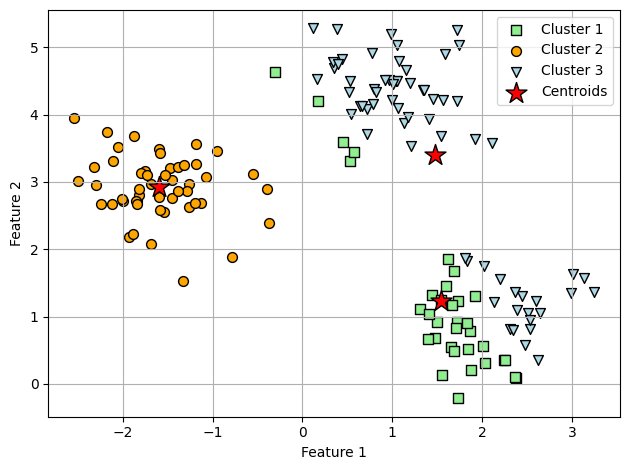

In [146]:
plot_km()

In [145]:
my_km.compute_new_centroids()

Run for selected iteration or tolerance reached.

Iteration : 4
Centroid change : 0.0


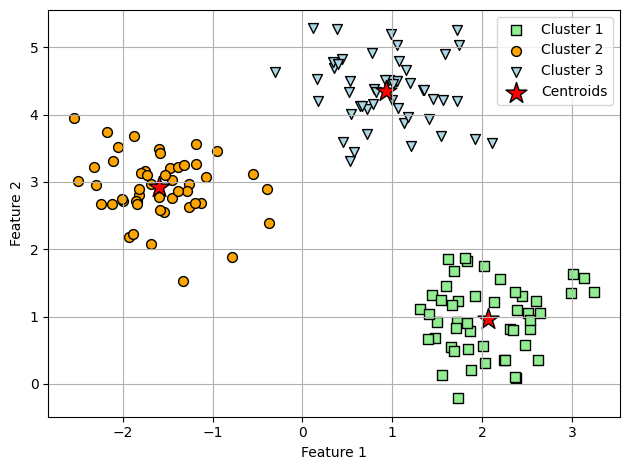

In [156]:
my_km = k_Means_2D(n_clusters=3,max_iter=200, tol = 1e-4)
my_y_km = my_km.fit_predict(X)
plot_km()

#### 8.1.2 k-means clustering using scikit-learn

From Chapter 10 of [1]. 

**Note :** Reference [1] and [2] use slightly different notations in math equations, though the underlying principles are the same. We choose to maintain mostly original notations for each source, with comments for clarification. 

Although k-means clustering can be applied to data in higher dimensions, we will walk through the 
following examples using a simple two-dimensional dataset for the purpose of visualization. 

In [2]:
from sklearn.datasets import make_blobs


X, y = make_blobs(n_samples=150, 
                  n_features=2, 
                  centers=3, 
                  cluster_std=0.5, 
                  shuffle=True, 
                  random_state=0)

The dataset that we just created consists of 150 randomly generated points that are roughly grouped 
into three regions with higher density, which is visualized via a two-dimensional scatterplot.

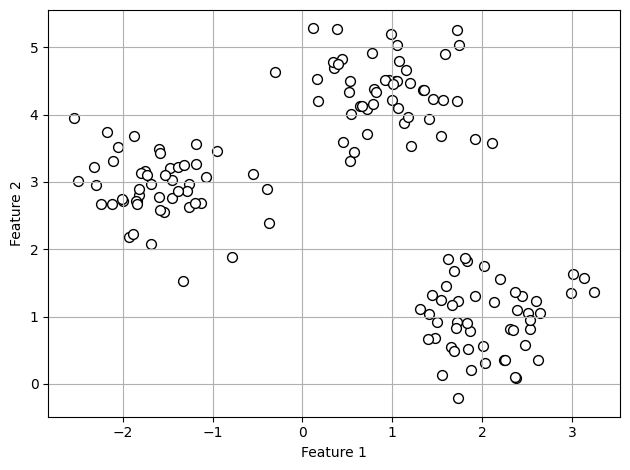

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], 
            c='white', marker='o', edgecolor='black', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.grid()
plt.tight_layout()
plt.show()

In real-world applications of clustering, we do not have any ground-truth category information 
(information provided as empirical evidence as opposed to inference) about those examples; if we were 
given class labels, this task would fall into the category of supervised learning. Thus, our goal is to 
group the examples based on their feature similarities, which can be achieved using the k-means 
algorithm, as summarized by the following four steps:

1. Randomly pick $k$ centroids from the examples as initial cluster centers
2. Assign each example to the nearest centroid, $\mu_j, j = 1,\ldots k$
3. Move the centroids to the center of the examples that were assigned to it
4. Repeat steps 2 and 3 until the cluster assignments do not change or a user-defined tolerance 
or maximum number of iterations is reached

Now, the next question is, how do we measure similarity between objects? We can define similarity as the 
opposite of distance, and a commonly used distance for clustering examples with continuous features 
is the **squared Euclidean distance** between two points, $x$ and $y$, in $m$-dimensional space
$$
d(x,y)^2 = \sum_{j=1}^m(x_j - y_j)^2 = \lVert x - y \rVert_2^2 \tag{8.4}
$$

Note that, in the preceding equation, the index $j$ refers to the $j^{th}$ dimension (feature column) of the 
example inputs, $x$ and $y$. 

Based on this Euclidean distance metric, we can describe the k-means algorithm as a simple optimization problem, an iterative approach for minimizing the within-cluster **sum of squared errors (SSE)**, 
which is sometimes also called **cluster inertia** 
$$
SSE = \sum_{i=1}^{n}\sum_{j=1}^{k}w^{(i,j)}\lVert x^{(i)} - \mu_j \rVert_2^2 \tag{8.5}
$$

Here, $\mu_j$ is the representative point (centroid) for cluster $j$. $w^{(i, j)}= 1$ if the example  $x^{(i)}$, is in cluster $j$, or $0$ otherwise. 
$$
w^{(i,j)} = 
\begin{cases}
1, \;\text{if} \; x^{(i)} \in j \\
0, \;\text{otherwise}
\end{cases} \tag{8.6}
$$

**Note :** $w^{(i,j)}$ in (8.6) is similar to $1\{C^{(i)}= j\}$ In (8.3).

Now that you have learned how the simple k-means algorithm works, let’s apply it to our example 
dataset using the KMeans class from scikit-learn’s cluster module. 

In [4]:
from sklearn.cluster import KMeans


km = KMeans(n_clusters=3, 
            init='random', 
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_km = km.fit_predict(X)

In [19]:
y_km.shape

(150,)

In [6]:
X.shape

(150, 2)

Using the preceding code, we set the number of desired clusters to 3; having to specify the number of
clusters a priori is one of the limitations of k-means. We set n_init=10 to run the k-means clustering
algorithms 10 times independently, with different random centroids to choose the final model as the
one with the lowest SSE. Via the max_iter parameter, we specify the maximum number of iterations
for each single run (here, 300). Note that the k-means implementation in scikit-learn stops early if it
converges before the maximum number of iterations is reached. However, it is possible that k-means
does not reach convergence for a particular run, which can be problematic (computationally expensive)
if we choose relatively large values for max_iter. One way to deal with convergence problems
is to choose larger values for tol, which is a parameter that controls the tolerance with regard to the
changes in the within-cluster SSE to declare convergence. In the preceding code, we chose a tolerance
of 1e-04 (=0.0001).

A problem with k-means is that one or more clusters can be empty. Note that this problem does not
exist for k-medoids or fuzzy C-means, an algorithm that we will discuss later in this section. However,
this problem is accounted for in the current k-means implementation in scikit-learn. If a cluster is
empty, the algorithm will search for the example that is farthest away from the centroid of the empty
cluster. Then, it will reassign the centroid to be this farthest point.

<hr>

**Feature Scaling**

When we are applying k-means to real-world data using a Euclidean distance metric, we
want to make sure that the features are measured on the same scale and apply z-score
standardization or min-max scaling if necessary.

<hr>

Having predicted the cluster labels, y_km, and discussed some of the challenges of the k-means algorithm, let’s now visualize the clusters that k-means identified in the dataset together with the cluster centroids. These are stored under the cluster_centers_ attribute of the fitted KMeans object.


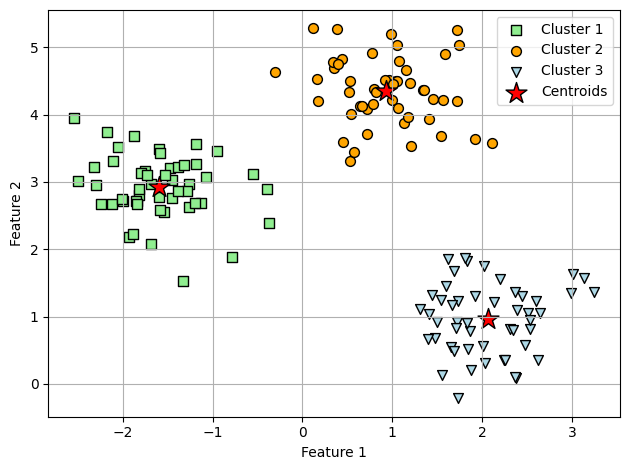

In [12]:
plt.scatter(X[y_km == 0, 0],
            X[y_km == 0, 1],
            s=50, c='lightgreen',
            marker='s', edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_km == 1, 0],
            X[y_km == 1, 1],
            s=50, c='orange',
            marker='o', edgecolor='black',
            label='Cluster 2')
plt.scatter(X[y_km == 2, 0],
            X[y_km == 2, 1],
            s=50, c='lightblue',
            marker='v', edgecolor='black',
            label='Cluster 3')
plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            s=250, marker='*',
            c='red', edgecolor='black',
            label='Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend(scatterpoints=1)
plt.grid()
plt.tight_layout()
plt.show()

In the figure above, you can see that k-means placed the three centroids at the center of each sphere, which looks like a reasonable grouping given this dataset.

Although k-means worked well on this toy dataset, we still have the drawback of having to specify
the number of clusters, $k$, a priori. The number of clusters to choose may not always be so obvious in
real-world applications, especially if we are working with a higher-dimensional dataset that cannot
be visualized. The other properties of k-means are that clusters do not overlap and are not hierarchical,
and we also assume that there is at least one item in each cluster.


### Related Videos

#### Lectures from top universities
<ul>
<li />CS229-2018 : <a href="https://youtu.be/rVfZHWTwXSA?si=UV3kkJd5hLA7pz2-">Lecture 14 : Expectation-Maximization Algorithms</a> 
<li />CS229-2022 : <a href="https://youtu.be/LMZZPneTcP4?si=yyNtXnx5Iwpj-urN">Lecture 12 : K-means, GMM and EM </a>
<li />MIT Machine learning 6.036 : <a href="https://youtu.be/BaZWcSq3IuI?si=jbusFioOt6eU2JBa">Lecture 13 : Clustering</a>
<li />University of Tübingen Machine Learning I : <a href="https://youtu.be/mU3GZaOoVDA?si=3j_tW6OXR6mFg3Me">09 - Clustering and expectation-maximization</a>
</ul>

#### General 
<ul>
<li />Andy McDonald : <a href="https://youtu.be/iNlZ3IU5Ffw?si=5gTlL5kh2wCOHwn5">K-Means Clustering Algorithm with Python Tutorial</a>

</ul>



### References

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022.  

2. A. Ng and T. Ma. [CS229 Lecture Notes.](https://cs229.stanford.edu/main_notes.pdf) Stanford University. 2023.




<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2025</div>